In [26]:
%run general_functions.ipynb

In [27]:
alk_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/alkalinity_mask_y2035.nc')
mesh_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')

In [29]:
data = (alk_mask['alk_flux']+mesh_mask['tmask']).isel(t=0,z=0)
data = data.where((-40 < data.nav_lon) & (data.nav_lon < 30) & (30 < data.nav_lat) & (data.nav_lat < 90), drop=True)
data = data.where(data)

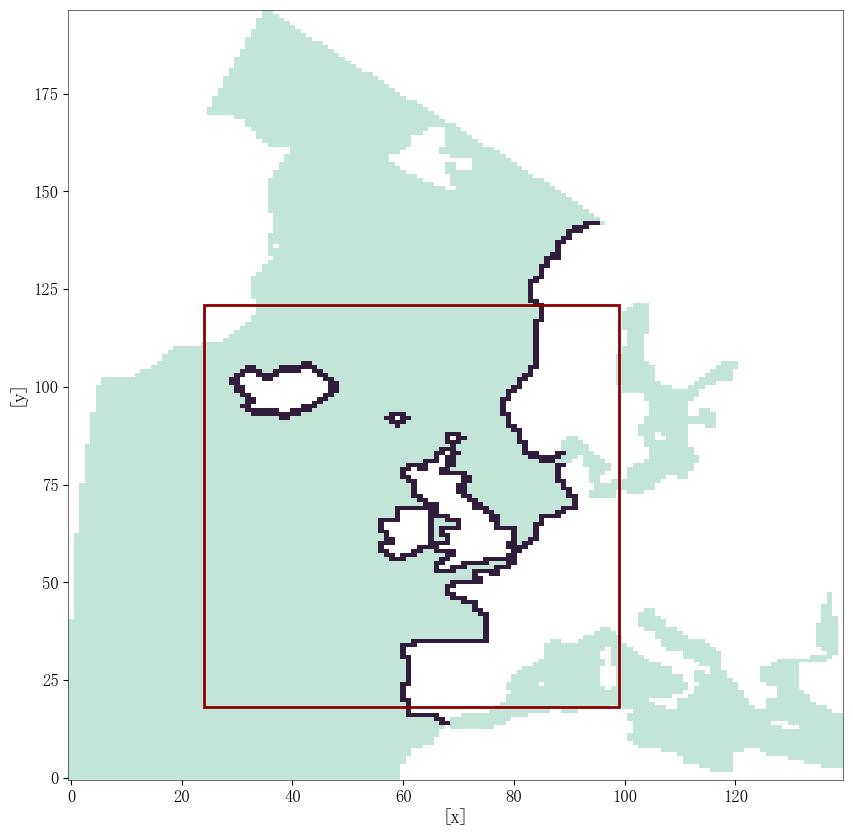

In [97]:
fig, ax = plt.subplots(
    figsize=(10, 10),
)

pcm = ax.pcolormesh(
    data.x, data.y, data,
    cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True),
    shading='auto',
)

                          # region of focus
rect = mpatches.Rectangle((24, 18), 75, 103, linewidth=2, edgecolor='darkred', facecolor='none')
rect = ax.add_patch(rect)

ax.tick_params(
    axis='both',       # apply to both x and y axes
    which='both',      # major and minor ticks
    labelsize=12
)
ax.set_ylabel('[y]', fontsize=14)
ax.set_xlabel('[x]', fontsize=14)

for location in ['left','bottom', 'right', 'top']:
    ax.spines[location].set_linewidth(0.4)

pass

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/alkalinityAddition.png')